# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## Table of Contents

### 1. What is DBSCAN?

### 2. DBSCAN in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for DBSCAN




### 1. What is DBSCAN?

DBSCAN is a density-based clustering algorithm that groups together points that are closely packed together, while labeling points in low-density regions as outliers

## How DBSCAN Works:

### Step 1: Define Density
- For each point, find its **neighbors within a distance `eps`**.  
- Count how many neighbors are inside this radius.  

A point is considered a **core point** if it has at least `min_samples` neighbors


### Step 2: Identify Core, Border and Noise Points

1. **Core point** → dense region  
2. **Border point** → not dense itself, but within `eps` of a core point  
3. **Noise point** → neither core nor border (isolated points)
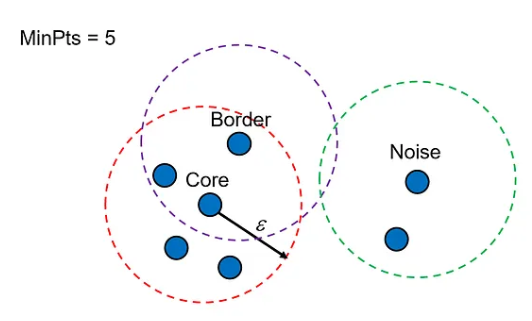

### Step 3: Form Clusters
- Start with an unvisited point:
  1. If it is a **core point**, create a new cluster  
  2. Expand the cluster by adding **all neighbors** within `eps`
- Recursively check neighbors:
  - If neighbor is a core point, add its neighbors too  
  - If neighbor is a border point, add it to the cluster

- Continue until all reachable points from this core point are assigned.


### Step 4: Handle Remaining Points
- Any point that is not assigned to a cluster is labeled as **noise (-1)**.


### Step 5: Output
- Each cluster gets a unique label  
- Noise points are labeled `-1`  

###Result: clusters + noise points

## 2. DBSCAN in Scikit-Learn

### **Most Important Parameters**

#### **1. `epslon`**

Maximum distance between two points for them to be considered neighbors. Controls how close points must be to form clusters

- Smaller `eps` → more points are labeled as **noise**  

- Larger `eps` → clusters may merge, fewer noise points  


#### **2. `min_samples`**

Minimum number of points required to form a **dense region (core point)**. Determines how strict the algorithm is about forming clusters.

**Default:** 5  

- Smaller → clusters form more easily, fewer noise points

- Larger → only dense regions form clusters, more noise points  

**Notes:**  

Often set to **double number of dimension** for small datasets, or higher for noisy data

#### **3. `metric`**
  
Distance metric used to calculate proximity between points. Determines which points are considered “neighbors”

**Default:** `euclidean`

**Common options:**  
  - `euclidean` → straight-line distance; most common for numeric features  
  - `manhattan` → sum of absolute differences; robust to outliers  
  - `cosine` → measures angle between vectors; useful for text embeddings  

**Rule of thumb:**  
Choice of metric affects cluster shape and which points are considered close.  

## Apply DBSCAN to a simple Dataset

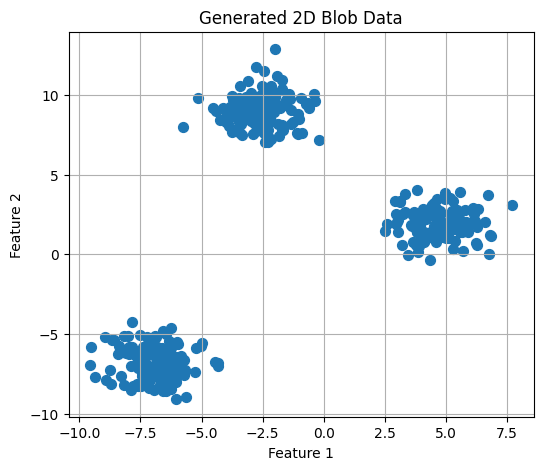

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import seaborn as sns
from sklearn.cluster import DBSCAN


# Generate 2D data: 400 points, 3 centers
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

In [ ]:

# Create DBSCAN model
dbscan = DBSCAN(
    eps=1.2,        # neighborhood radius
    min_samples=5,  # minimum points to form a cluster
    metric='euclidean'
)

# Fit and predict cluster labels
labels = dbscan.fit_predict(X)

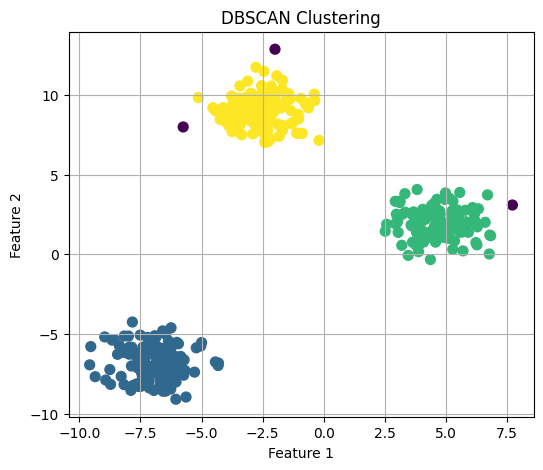

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

# Compute silhouette score, ignoring noise points
mask = labels != -1
score = silhouette_score(X[mask], labels[mask])
print("Silhouette Score (excluding noise points):", score)

Silhouette Score (excluding noise points): 0.8480963132111413


In [ ]:
outlier_percent = []

for eps in np.linspace(0.001,3,50):

    # Create Model
    dbscan = DBSCAN(eps=eps)
    cluster_labels = dbscan.fit_predict(X)


    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(cluster_labels)

    outlier_percent.append(perc_outliers)

Text(0.5, 0, 'Epsilon Value')

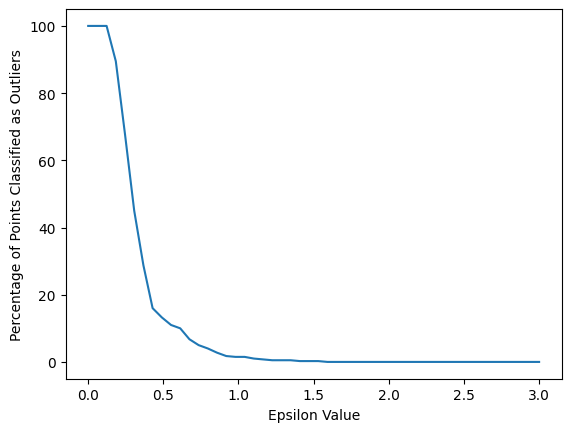

In [ ]:
sns.lineplot(x=np.linspace(0.001,3,50),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")

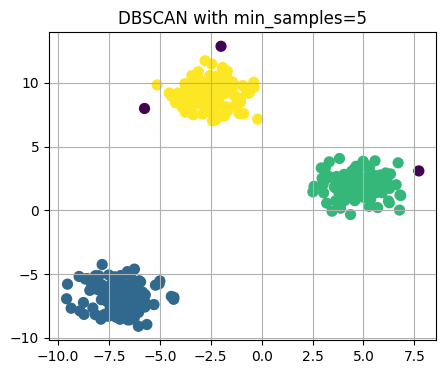

min_samples=5 → Silhouette Score: 0.848


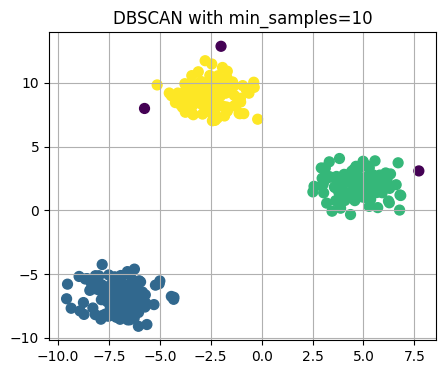

min_samples=10 → Silhouette Score: 0.848


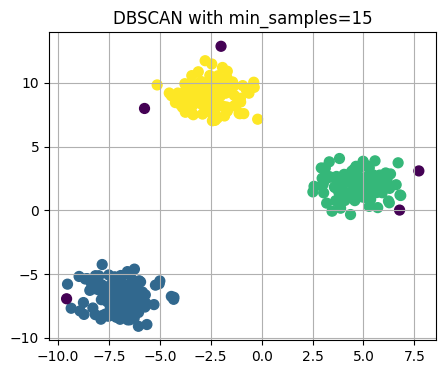

min_samples=15 → Silhouette Score: 0.849


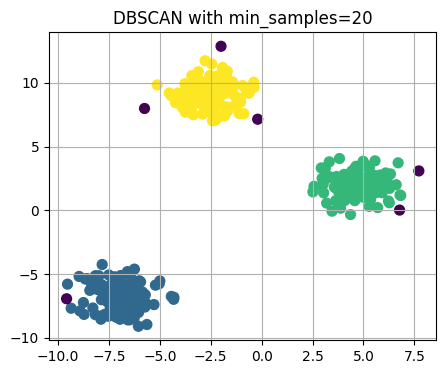

min_samples=20 → Silhouette Score: 0.850


In [ ]:
#Varying min_samples
min_samples_values = [5, 10, 15, 20]

for min_samples in min_samples_values:
    # Apply DBSCAN
    dbscan = DBSCAN(eps=1.2, min_samples=min_samples)
    labels = dbscan.fit_predict(X)

    # Visualize clusters
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
    plt.title(f"DBSCAN with min_samples={min_samples}")
    plt.grid(True)
    plt.show()

    # Compute silhouette score (ignore noise)
    mask = labels != -1  # exclude noise
    if len(set(labels[mask])) > 1:  # silhouette score requires >=2 clusters
        score = silhouette_score(X[mask], labels[mask])
        print(f"min_samples={min_samples} → Silhouette Score: {score:.3f}")
    else:
        print(f"min_samples={min_samples} → Too few clusters to compute silhouette score")

## Task 2B: DBSCAN

Dataset: `CC GENERAL.csv`  
Goal: Use **DBSCAN** to find clusters of customers and identify potential outliers.


## 1. Exploratory Data Analysis (EDA)



In [3]:
import pandas as pd

df = pd.read_csv("CC GENERAL.csv")

df.head(), df.shape

(  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
 0  C10001    40.900749           0.818182      95.40              0.00   
 1  C10002  3202.467416           0.909091       0.00              0.00   
 2  C10003  2495.148862           1.000000     773.17            773.17   
 3  C10004  1666.670542           0.636364    1499.00           1499.00   
 4  C10005   817.714335           1.000000      16.00             16.00   
 
    INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
 0                    95.4      0.000000             0.166667   
 1                     0.0   6442.945483             0.000000   
 2                     0.0      0.000000             1.000000   
 3                     0.0    205.788017             0.083333   
 4                     0.0      0.000000             0.083333   
 
    ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
 0                    0.000000                          0.083333   
 1                  

In [5]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [6]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Numeric columns:", list(numeric_cols))
print("Categorical columns:", list(categorical_cols))

Numeric columns: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']
Categorical columns: ['CUST_ID']


In [7]:
df.isna().sum().sort_values(ascending=False).head(20)

,0
MINIMUM_PAYMENTS,313
CREDIT_LIMIT,1
BALANCE,0
CUST_ID,0
BALANCE_FREQUENCY,0
PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0


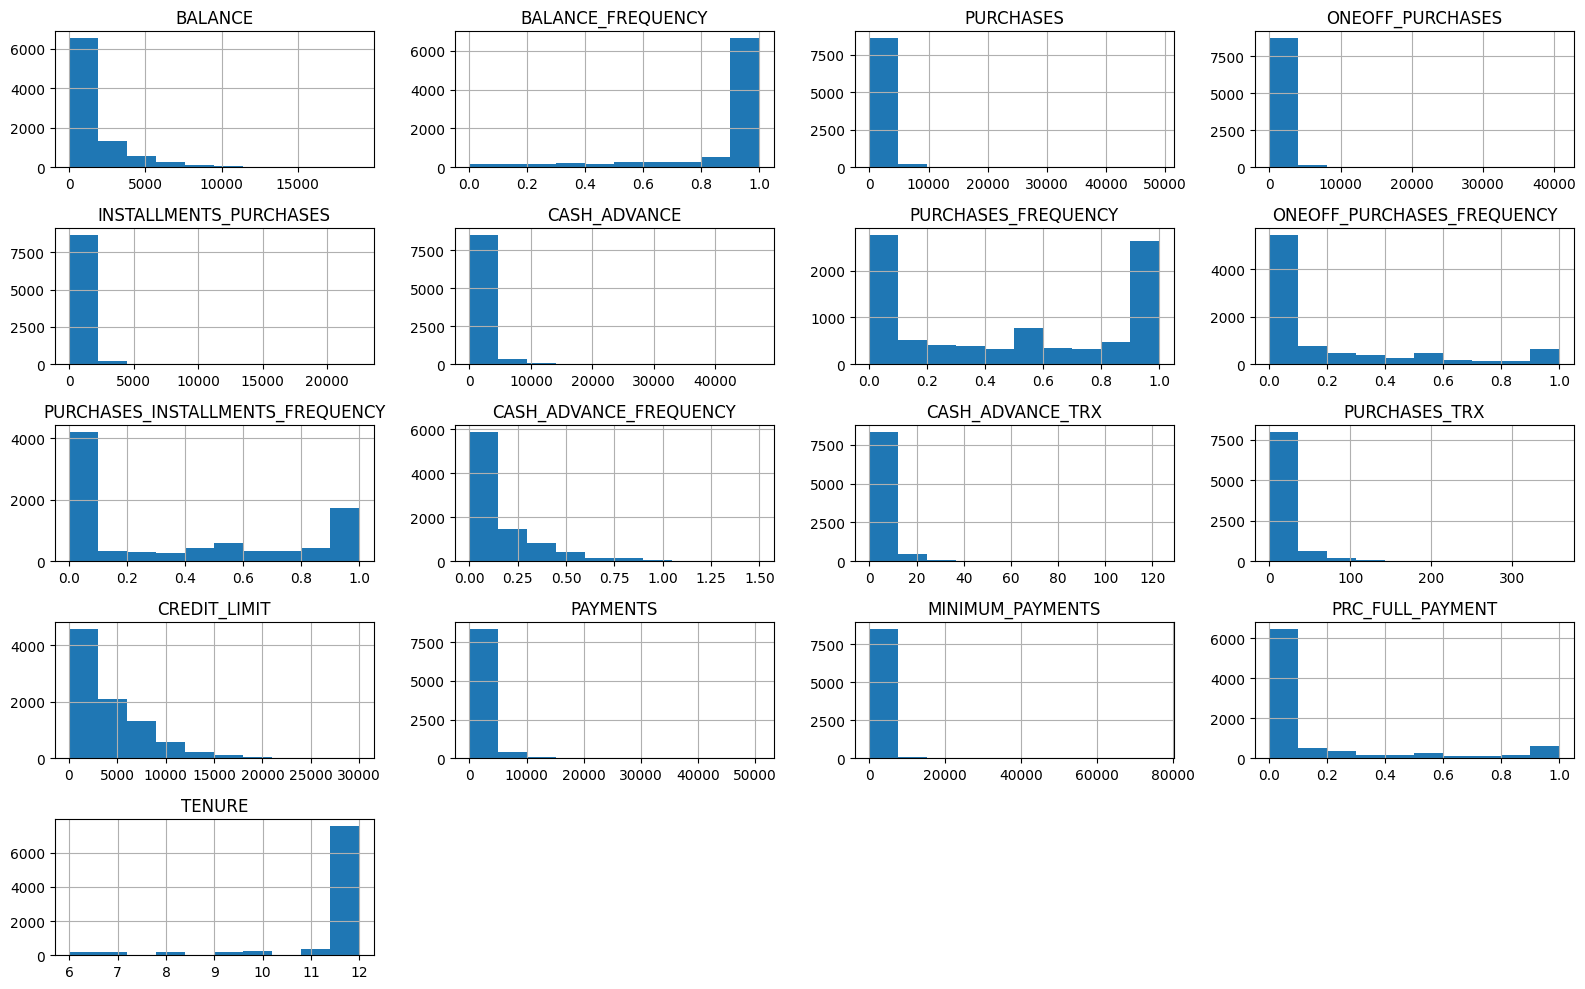

,0
MINIMUM_PAYMENTS,13.622797
ONEOFF_PURCHASES,10.045083
PURCHASES,8.144269
INSTALLMENTS_PURCHASES,7.299120
PAYMENTS,5.907620
CASH_ADVANCE_TRX,5.721298
CASH_ADVANCE,5.166609
PURCHASES_TRX,4.630655
BALANCE,2.393386
PRC_FULL_PAYMENT,1.942820


In [10]:
import matplotlib.pyplot as plt
df[numeric_cols].hist(figsize=(16,10))
plt.tight_layout()
plt.show()

df[numeric_cols].skew().sort_values(ascending=False).head(15)

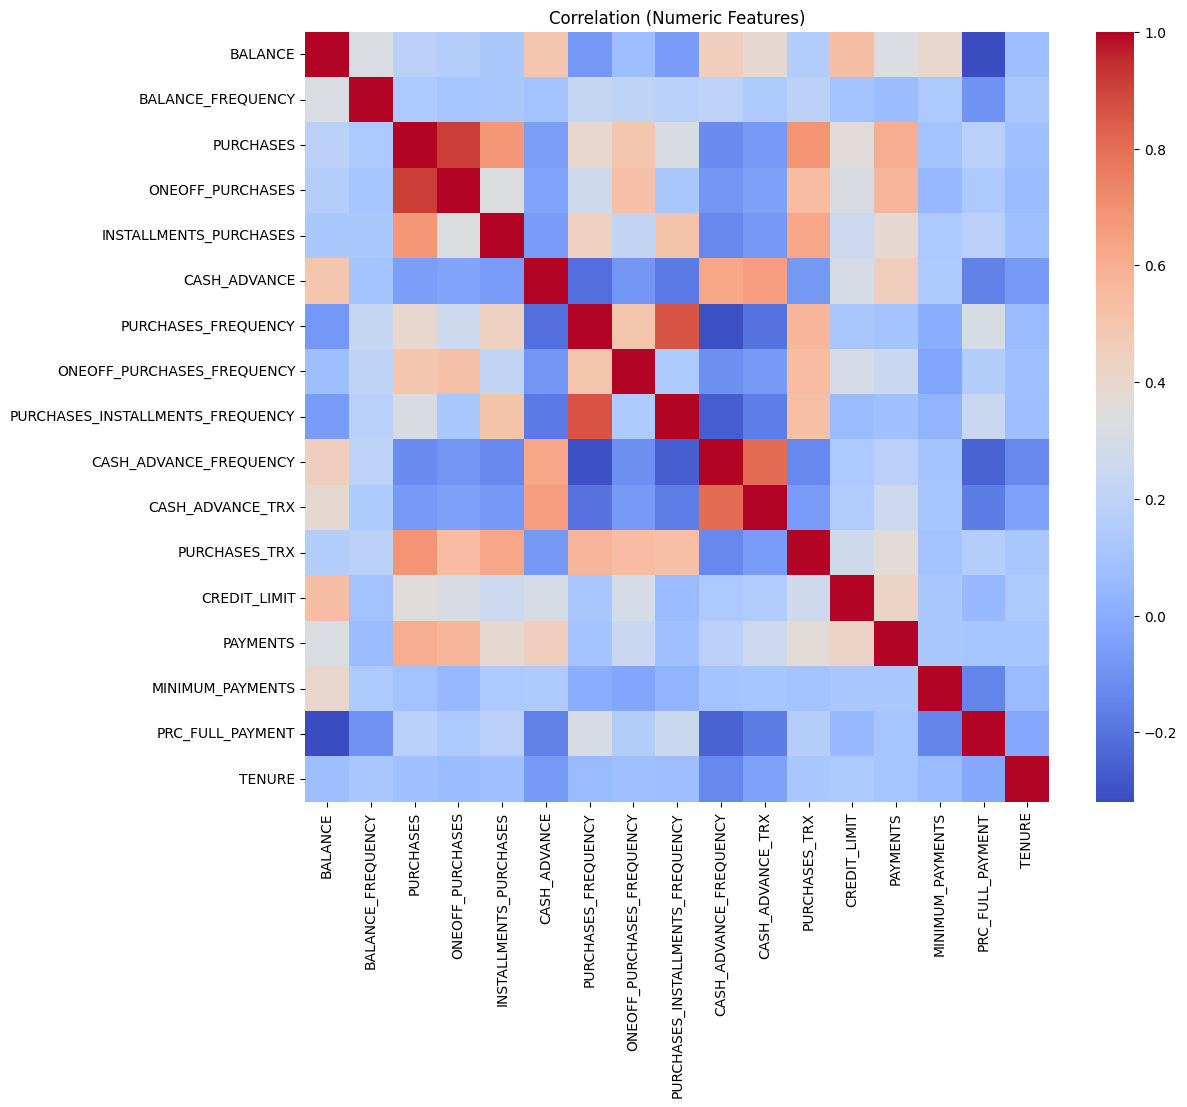

In [11]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm")
plt.title("Correlation (Numeric Features)")
plt.show()

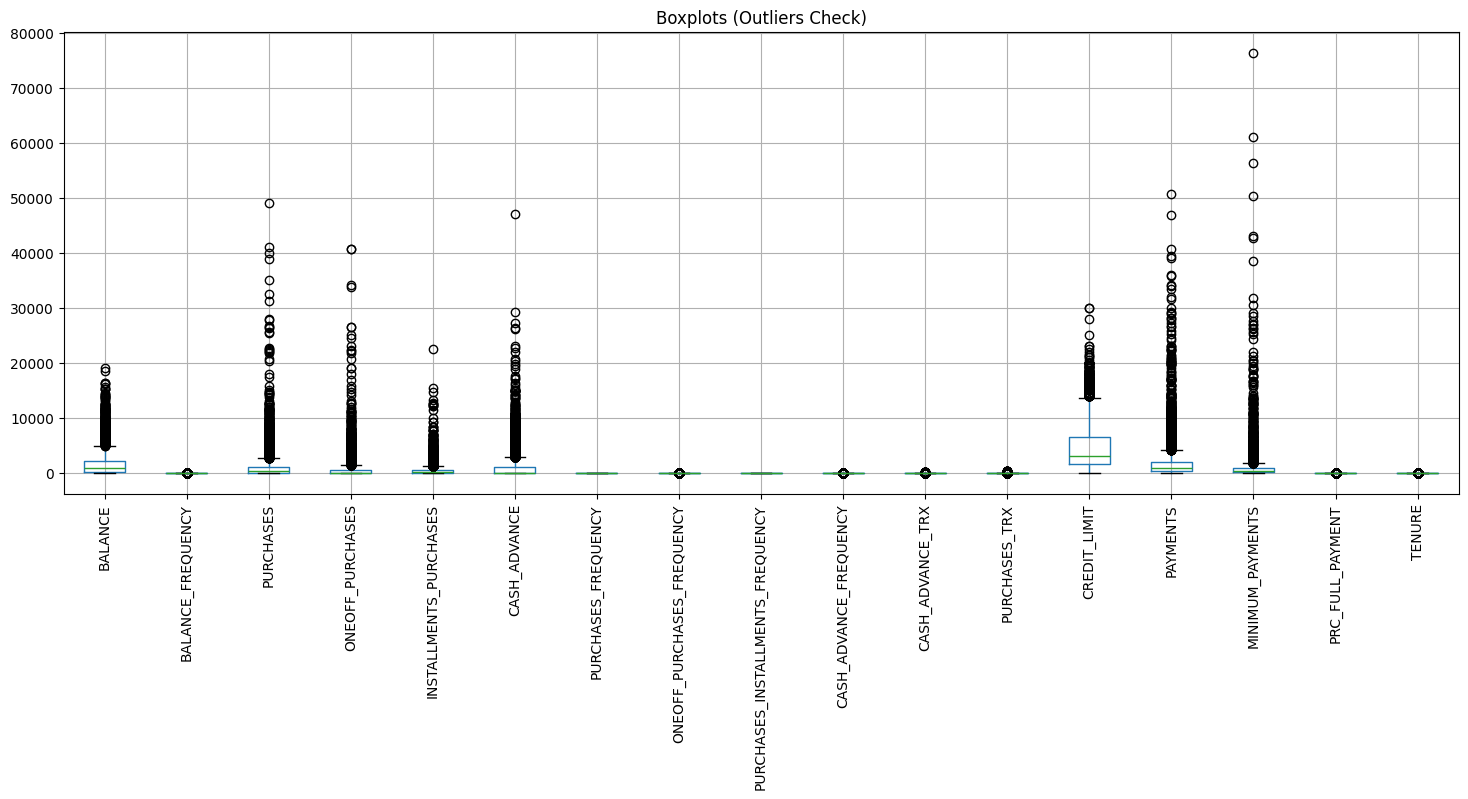

In [12]:
plt.figure(figsize=(18,6))
df[numeric_cols].boxplot(rot=90)
plt.title("Boxplots (Outliers Check)")
plt.show()

## 2. Data Preparation

In [13]:
import pandas as pd
import numpy as np

df_prep = df.copy()

# Drop ID-like columns (common in CC GENERAL)
id_cols = [c for c in ["CUST_ID", "CUSTOMER_ID", "ID"] if c in df_prep.columns]
df_prep.drop(columns=id_cols, inplace=True, errors="ignore")

print("Dropped columns:", id_cols)
print("Shape after dropping:", df_prep.shape)

Dropped columns: ['CUST_ID']
Shape after dropping: (8950, 17)


In [14]:
categorical_cols = df_prep.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", categorical_cols)

if len(categorical_cols) > 0:
    df_prep = pd.get_dummies(df_prep, columns=categorical_cols, drop_first=False)
    print("One-hot encoding applied.")
else:
    print("No categorical columns found (already numeric).")

print("Shape after encoding:", df_prep.shape)

Categorical columns: []
No categorical columns found (already numeric).
Shape after encoding: (8950, 17)


In [15]:
missing_before = df_prep.isna().sum().sum()
print("Total missing values BEFORE:", missing_before)

for col in df_prep.columns:
    if df_prep[col].isna().any():
        df_prep[col] = df_prep[col].fillna(df_prep[col].median())

missing_after = df_prep.isna().sum().sum()
print("Total missing values AFTER:", missing_after)

Total missing values BEFORE: 314
Total missing values AFTER: 0


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_prep)

print("Scaled matrix shape:", X_scaled.shape)

Scaled matrix shape: (8950, 17)


In [17]:
# 1) Check any remaining NaNs (should be 0)
print("NaNs in scaled matrix:", np.isnan(X_scaled).sum())

# 2) Check any remaining non-numeric columns (should be empty)
non_numeric_cols = df_prep.select_dtypes(include=["object"]).columns.tolist()
print("Non-numeric columns remaining:", non_numeric_cols)

# 3) Final shape
print("Final prepared df shape:", df_prep.shape)

NaNs in scaled matrix: 0
Non-numeric columns remaining: []
Final prepared df shape: (8950, 17)


## 3. Apply DBSCAN




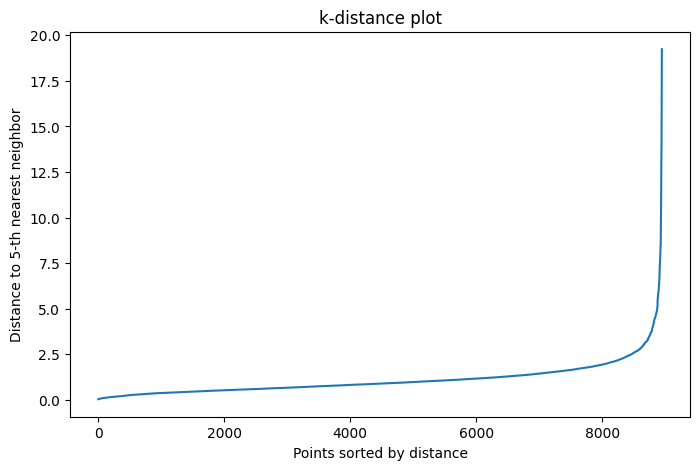

In [39]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 5   # choose a starting value

nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.title("k-distance plot")
plt.show()

In [38]:
for eps in [1,1.2,1.4,1.6,1.8,2.0, 2.2, 2.4, 2.6, 2.8]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)

    unique = np.unique(labels)
    n_clusters = len(unique[unique != -1])
    n_noise = np.sum(labels == -1)
    noise_pct = 100 * n_noise / len(labels)

    print(f"eps={eps} → clusters={n_clusters}, noise={noise_pct:.2f}%")

eps=1 → clusters=15, noise=34.44%
eps=1.2 → clusters=7, noise=24.19%
eps=1.4 → clusters=5, noise=17.11%
eps=1.6 → clusters=3, noise=12.57%
eps=1.8 → clusters=3, noise=9.14%
eps=2.0 → clusters=2, noise=6.69%
eps=2.2 → clusters=1, noise=5.26%
eps=2.4 → clusters=1, noise=4.18%
eps=2.6 → clusters=1, noise=3.53%
eps=2.8 → clusters=1, noise=2.77%


In [35]:
from sklearn.cluster import DBSCAN
import numpy as np

dbscan = DBSCAN(eps=1.2, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

print("Unique labels:", np.unique(labels))

Unique labels: [-1  0  1  2  3  4  5  6]


## 4. Evaluate the Clustering

In [36]:
from sklearn.metrics import silhouette_score

unique_labels = np.unique(labels)
n_clusters = len(unique_labels[unique_labels != -1])
n_noise = np.sum(labels == -1)

print("Number of clusters (excluding noise):", n_clusters)
print("Number of noise points:", n_noise)
print("Percent noise:", round(100*n_noise/len(labels),2), "%")

mask = labels != -1
if n_clusters >= 2:
    sil = silhouette_score(X_scaled[mask], labels[mask])
    print("Silhouette score:", round(sil,4))
else:
    print("Silhouette not computed (need >=2 clusters)")

Number of clusters (excluding noise): 7
Number of noise points: 2165
Percent noise: 24.19 %
Silhouette score: -0.1125
